In [2]:
from matplotlib import pyplot as plt
import numpy as np
import os
import glob
from RVSS_EOS_Slope import RVSS_EOS_Slope as rvss_eos
from scipy.interpolate import PchipInterpolator,interp1d
from scipy.integrate import quad
from scipy.stats import linregress
from Modules.TOV_Solver_RK45 import TovSolverRK45 as tov
from Modules.TOV_Solver_RK45_Tide import TovSolverTidalRK45 as tov_tides
import kuibit.simdir as SD
from matplotlib.lines import Line2D
from scipy.stats import linregress
import pickle

In [8]:
EGW_T_data_1p3 = np.loadtxt('./Figure_Data/GW/EGW_Tot_cs2prime_1p3.txt')
EGW_T_data_1p4 = np.loadtxt('./Figure_Data/GW/EGW_Tot_cs2prime_1p4.txt')
EGW_T_data_1p35 = np.loadtxt('./Figure_Data/GW/EGW_Tot_cs2prime_1p35.txt')

In [9]:
print(EGW_T_data_1p4)

[[0.003985   0.03312815]
 [0.002112   0.05918722]
 [0.00171    0.04463985]
 [0.001239   0.03415128]
 [0.002761   0.03415128]]


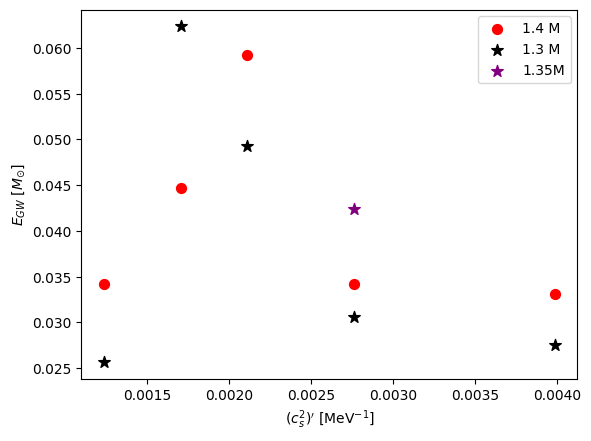

In [14]:
alpha_list = EGW_T_data_1p4[:,0]
E_tot_GW_1p4 = EGW_T_data_1p4[:,1]

alpha_list_1p3 = EGW_T_data_1p3[:,0]
E_tot_GW_1p3 = EGW_T_data_1p3[:,1]

E_tot_GW_1p35 = EGW_T_data_1p35[1]


plt.scatter(alpha_list,E_tot_GW_1p4,s=50,label='1.4 M',color='red')
plt.scatter(alpha_list_1p3,E_tot_GW_1p3,s=75,label='1.3 M',color='black',marker='*')
plt.scatter(alpha_list[-1],E_tot_GW_1p35,s=75,label='1.35M',color='Purple',marker='*')
plt.ylabel(r'$E_{GW}$ [$M_{\odot}$]')
plt.xlabel(r"$(c_s^2)'$ [$\text{MeV}^{-1}$]")
plt.legend()
plt.savefig('./Figures/Final_Paper_Figs/EGW_T_csp.pdf',format='pdf',dpi=300)
plt.show()


In [15]:
EOS_V_Energy_1p4_d = np.loadtxt('./Figure_Data/GW/EOS_V_EGW_1p4.txt')
EOS_IV_Energy_1p4_d = np.loadtxt('./Figure_Data/GW/EOS_IV_EGW_1p4.txt')
EOS_III_Energy_1p4_d = np.loadtxt('./Figure_Data/GW/EOS_III_EGW_1p4.txt')
EOS_II_Energy_1p4_d = np.loadtxt('./Figure_Data/GW/EOS_II_EGW_1p4.txt')
EOS_I_Energy_1p4_d = np.loadtxt('./Figure_Data/GW/EOS_I_EGW_1p4.txt')

EOS_V_Energy_1p3_d = np.loadtxt('./Figure_Data/GW/EOS_V_EGW_1p3.txt')
EOS_IV_Energy_1p3_d = np.loadtxt('./Figure_Data/GW/EOS_IV_EGW_1p3.txt')
EOS_III_Energy_1p3_d = np.loadtxt('./Figure_Data/GW/EOS_III_EGW_1p3.txt')
EOS_II_Energy_1p3_d = np.loadtxt('./Figure_Data/GW/EOS_II_EGW_1p3.txt')
EOS_I_Energy_1p3_d = np.loadtxt('./Figure_Data/GW/EOS_I_EGW_1p3.txt')

EOS_IV_Energy_1p35_d = np.loadtxt('./Figure_Data/GW/EOS_IV_EGW_1p35.txt')


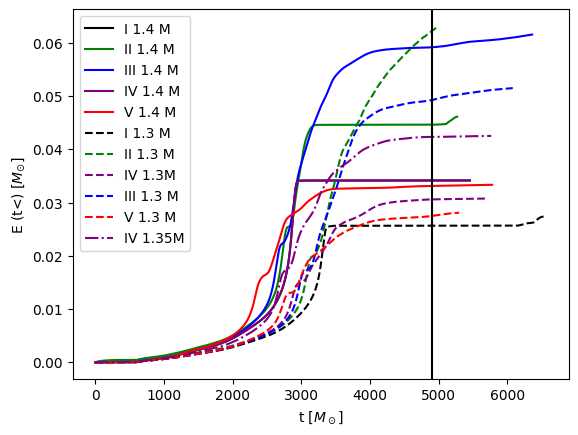

In [19]:
plt.plot(EOS_I_Energy_1p4_d[:,0],EOS_I_Energy_1p4_d[:,1],label=r'I 1.4 M', color = 'black')
plt.plot(EOS_II_Energy_1p4_d[:,0],EOS_II_Energy_1p4_d[:,1],label=r'II 1.4 M',color='green')
plt.plot(EOS_III_Energy_1p4_d[:,0],EOS_III_Energy_1p4_d[:,1],label=r'III 1.4 M',color='blue')
plt.plot(EOS_IV_Energy_1p4_d[:,0],EOS_IV_Energy_1p4_d[:,1],label=r'IV 1.4 M',linestyle='-',color='purple')
plt.plot(EOS_V_Energy_1p4_d[:,0],EOS_V_Energy_1p4_d[:,1],label=r'V 1.4 M',color = 'red')

plt.plot(EOS_I_Energy_1p3_d[:,0],EOS_I_Energy_1p3_d[:,1],label=r'I 1.3 M',linestyle = '--',color='black')
plt.plot(EOS_II_Energy_1p3_d[:,0],EOS_II_Energy_1p3_d[:,1],label=r'II 1.3 M',linestyle='--',color = 'green')
plt.plot(EOS_IV_Energy_1p3_d[:,0],EOS_IV_Energy_1p3_d[:,1],label=r'IV 1.3M',linestyle = '--',color = 'purple')
plt.plot(EOS_III_Energy_1p3_d[:,0],EOS_III_Energy_1p3_d[:,1],label=r'III 1.3 M',linestyle = '--',color='blue')
plt.plot(EOS_V_Energy_1p3_d[:,0],EOS_V_Energy_1p3_d[:,1],label=r'V 1.3 M',linestyle = '--',color='red')

plt.plot(EOS_IV_Energy_1p35_d[:,0],EOS_IV_Energy_1p35_d[:,1],label=r'IV 1.35M',linestyle='-.',color = 'purple')

plt.axvline(x = 4900,color='black')
plt.ylabel(r'E (t<) [$M_{\odot}$]')
plt.xlabel(r't [$M_\odot$]')
plt.legend()

plt.savefig('./Figures/Final_Paper_Figs/EGW_cum.pdf',format='pdf',dpi=300)

plt.show()

In [20]:
asd_data_V_1p4 = np.loadtxt('./Figure_Data/GW/EOS_V_asd_1p4.txt')
asd_data_III_1p4 = np.loadtxt('./Figure_Data/GW/EOS_III_asd_1p4.txt')
asd_data_V_1p3 = np.loadtxt('./Figure_Data/GW/EOS_V_asd_1p3.txt')
asd_data_IV_1p3 = np.loadtxt('./Figure_Data/GW/EOS_IV_asd_1p3.txt')
asd_data_III_1p3 = np.loadtxt('./Figure_Data/GW/EOS_III_asd_1p3.txt')
asd_data_II_1p3 = np.loadtxt('./Figure_Data/GW/EOS_II_asd_1p3.txt')

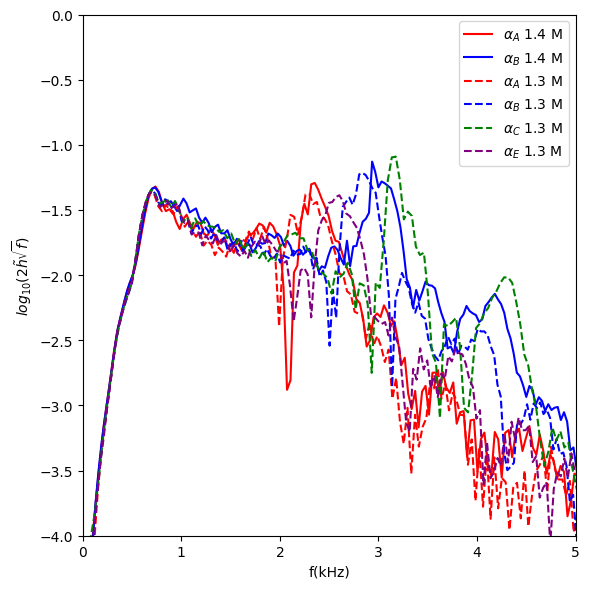

In [22]:
plt.figure(figsize=(6,6))
plt.xlim([0,5])
plt.ylim([-4,0])
plt.xlabel('f(kHz)')
plt.ylabel(r'$log_{10}(2\tilde{h}\sqrt{f} )$')
plt.plot(asd_data_V_1p4[:,0],asd_data_V_1p4[:,1],'red',label=r'$\alpha_A$ 1.4 M')
plt.plot(asd_data_III_1p4[:,0],asd_data_III_1p4[:,1],'blue',label=r'$\alpha_B$ 1.4 M')


plt.plot(asd_data_V_1p3[:,0],asd_data_V_1p3[:,1],'red',label=r'$\alpha_A$ 1.3 M',linestyle='--')
plt.plot(asd_data_III_1p3[:,0],asd_data_III_1p3[:,1],'blue',label=r'$\alpha_B$ 1.3 M',linestyle='--')
plt.plot(asd_data_II_1p3[:,0],asd_data_II_1p3[:,1],'green',label=r'$\alpha_C$ 1.3 M',linestyle='--')
plt.plot(asd_data_IV_1p3[:,0],asd_data_IV_1p3[:,1],'purple',label=r'$\alpha_E$ 1.3 M',linestyle = '--')
plt.tight_layout()
plt.legend()

plt.savefig('./Figures/Final_Paper_Figs/ASD_vs_f_noBH.pdf',format='pdf',dpi=300)

plt.show()

In [23]:
f2_list_1p4 = np.loadtxt('./Figure_Data/GW/f2_vs_cs2prime_1p4.txt')
f2_list_1p3 = np.loadtxt('./Figure_Data/GW/f2_vs_cs2prime_1p3.txt')
f2_list_1p35 = np.loadtxt('./Figure_Data/GW/f2_vs_cs2prime_1p35.txt')

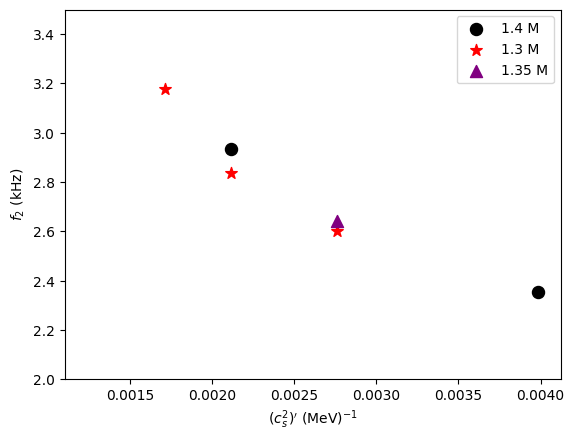

In [26]:
plt.scatter(f2_list_1p4[:,0],f2_list_1p4[:,1],s=75,marker='o',label='1.4 M', color = 'black')
plt.scatter(f2_list_1p3[:,0],f2_list_1p3[:,1],s=75,marker='*',label='1.3 M', color= 'red')
plt.scatter(f2_list_1p35[0],f2_list_1p35[1],s=75,marker='^',label='1.35 M',color= 'purple')
plt.ylim([2.0,3.5])
plt.xlabel(r"$(c_s^2)'\text{ (MeV)}^{-1}$")
plt.ylabel(r"$f_2 \text{ (kHz)}$")
plt.legend()

plt.savefig('./Figures/Final_Paper_Figs/f2_vs_cs2prime.pdf',format='pdf',dpi=300)


In [27]:
mshock_1p4_data = np.loadtxt('./Figure_Data/GW/Mshock_norm_1p4.txt')
mshock_1p3_data = np.loadtxt('./Figure_Data/GW/Mshock_norm_1p3.txt')
mshock_1p35_data = np.loadtxt('./Figure_Data/GW/Mshock_norm_1p35.txt')

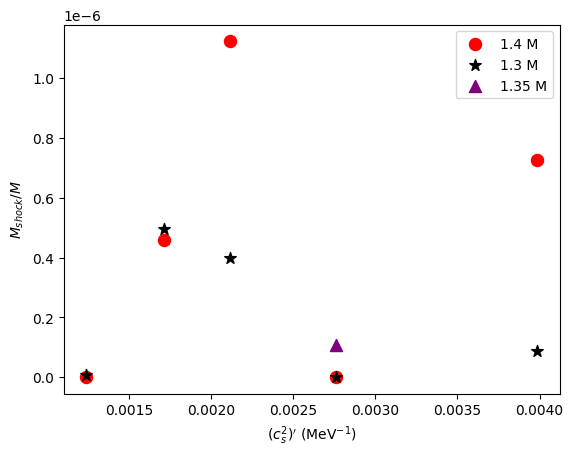

In [29]:
plt.scatter(mshock_1p4_data[:,0],mshock_1p4_data[:,1],color='red',marker='o',s=75,label='1.4 M')
plt.scatter(mshock_1p3_data[:,0],mshock_1p3_data[:,1],color = 'black',marker = '*', s = 75,label = '1.3 M')
plt.scatter(mshock_1p35_data[0],mshock_1p35_data[1],color='purple',marker='^', s = 75, label= '1.35 M')
plt.xlabel(r"$(c_s^2)'\text{ (MeV}^{-1}$)")
plt.ylabel(r'$M_{shock}/M$')
plt.legend()
plt.savefig('./Figures/Final_Paper_Figs/Mshock_normalized.pdf',format='pdf')